Dataset: I have used data of stock prices of 'Apple' from yahoo finance during the period

In [6]:
#Import Libraries
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from pmdarima import auto_arima
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, mean_absolute_percentage_error
import statsmodels.api as sm
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import LSTM
from tensorflow.keras.layers import GRU
import warnings
warnings.filterwarnings("ignore")

In [7]:
#! pip install pmdarima

In [8]:
# Download Apple's historical stock data
df = yf.download( "AAPL", start="2013-01-01", end="2026-05-05", interval="1d", auto_adjust=False)

[*********************100%***********************]  1 of 1 completed


In [9]:
df.head()

Price,Adj Close,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,,
2013-01-02,16.567118,19.608213,19.821428,19.343929,19.779285,560518000
2013-01-03,16.358002,19.360714,19.631071,19.321428,19.567142,352965200
2013-01-04,15.902352,18.821428,19.236786,18.779642,19.177500,594333600
2013-01-07,15.808813,18.710714,18.903570,18.400000,18.642857,484156400
2013-01-08,15.851352,18.761070,18.996071,18.616072,18.900356,458707200


## Dataset Features

| Feature | Description |
|---------|-------------|
| **Open** | The price at which Tesla stock started trading when the market opened for that day. |
| **High** | The highest price reached by Tesla stock during that trading day. |
| **Low** | The lowest price reached by Tesla stock during that trading day. |
| **Close** | The final price of Tesla stock when the market closed, representing the day's official closing value. |
| **Volume** | The total number of Tesla shares traded by investors during that trading day. |
|**Adjusted Close**| The final price of a stock for the day.

In [10]:
df.shape

(3354, 6)

In [11]:
# Display dataset summary
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 3354 entries, 2013-01-02 to 2026-05-04
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   (Adj Close, AAPL)  3354 non-null   float64
 1   (Close, AAPL)      3354 non-null   float64
 2   (High, AAPL)       3354 non-null   float64
 3   (Low, AAPL)        3354 non-null   float64
 4   (Open, AAPL)       3354 non-null   float64
 5   (Volume, AAPL)     3354 non-null   int64  
dtypes: float64(5), int64(1)
memory usage: 183.4 KB


In [12]:
df.isnull().sum()

,,0
Price,Ticker,
Adj Close,AAPL,0
Close,AAPL,0
High,AAPL,0
Low,AAPL,0
Open,AAPL,0
Volume,AAPL,0


In [13]:
# Statistical summray
df.describe()

Price,Adj Close,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL,AAPL
count,3354.000000,3354.000000,3354.000000,3354.000000,3354.000000,3.354000e+03
mean,96.595834,99.155977,100.142708,98.084627,99.077900,1.425680e+08
std,78.937294,78.624919,79.399010,77.782505,78.558215,1.199127e+08
min,11.853015,13.947500,14.271429,13.753571,13.856071,1.791060e+07
25%,26.433574,29.165625,29.423125,28.941250,29.195625,6.800870e+07
50%,52.871307,55.618750,55.998749,54.856251,55.519999,1.048003e+08
75%,162.867970,165.975002,167.857498,164.475002,165.957497,1.740057e+08
max,285.413116,286.190002,288.619995,283.299988,286.200012,1.460852e+09


In [14]:
# Saving the dataset
df.to_csv("apple_stock.csv")

In [15]:
# Display column names
df.columns

MultiIndex([('Adj Close', 'AAPL'),
            (    'Close', 'AAPL'),
            (     'High', 'AAPL'),
            (      'Low', 'AAPL'),
            (     'Open', 'AAPL'),
            (   'Volume', 'AAPL')],
           names=['Price', 'Ticker'])

In [16]:
# Removing ticker from column names
df.columns = df.columns.droplevel(1)

In [17]:
# Display column names
df.columns

Index(['Adj Close', 'Close', 'High', 'Low', 'Open', 'Volume'], dtype='object', name='Price')

In [18]:
df.head()

Price,Adj Close,Close,High,Low,Open,Volume
Date,,,,,,
2013-01-02,16.567118,19.608213,19.821428,19.343929,19.779285,560518000
2013-01-03,16.358002,19.360714,19.631071,19.321428,19.567142,352965200
2013-01-04,15.902352,18.821428,19.236786,18.779642,19.177500,594333600
2013-01-07,15.808813,18.710714,18.903570,18.400000,18.642857,484156400
2013-01-08,15.851352,18.761070,18.996071,18.616072,18.900356,458707200


In [19]:
# display datatypes of all columns
df.dtypes

,0
Price,
Adj Close,float64
Close,float64
High,float64
Low,float64
Open,float64
Volume,int64


In [20]:
# Display dataset summary
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 3354 entries, 2013-01-02 to 2026-05-04
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Adj Close  3354 non-null   float64
 1   Close      3354 non-null   float64
 2   High       3354 non-null   float64
 3   Low        3354 non-null   float64
 4   Open       3354 non-null   float64
 5   Volume     3354 non-null   int64  
dtypes: float64(5), int64(1)
memory usage: 183.4 KB


In [21]:
# Check missing values
df.isnull().sum()

,0
Price,
Adj Close,0
Close,0
High,0
Low,0
Open,0
Volume,0


In [22]:
# Save the cleaned dataset
df.to_csv('apple_stock.csv')

In [23]:
# Load cleaned dataset
df = pd.read_csv("apple_stock.csv", index_col=0)

In [24]:
df.head()

,Adj Close,Close,High,Low,Open,Volume
Date,,,,,,
2013-01-02,16.567118,19.608213,19.821428,19.343929,19.779285,560518000
2013-01-03,16.358002,19.360714,19.631071,19.321428,19.567142,352965200
2013-01-04,15.902352,18.821428,19.236786,18.779642,19.177500,594333600
2013-01-07,15.808813,18.710714,18.903570,18.400000,18.642857,484156400
2013-01-08,15.851352,18.761070,18.996071,18.616072,18.900356,458707200


In [25]:
print(df.columns)

Index(['Adj Close', 'Close', 'High', 'Low', 'Open', 'Volume'], dtype='object')


In [26]:
df.tail()

,Adj Close,Close,High,Low,Open,Volume
Date,,,,,,
2026-04-28,270.227753,270.709991,273.230011,268.660004,272.339996,40018900
2026-04-29,269.688721,270.170013,271.040009,267.040009,267.549988,30047900
2026-04-30,270.866638,271.350006,276.000000,268.140015,270.500000,91848200
2026-05-01,279.640991,280.140015,287.220001,278.369995,278.859985,79915400
2026-05-04,276.336823,276.829987,280.630005,274.859985,279.660004,46668400


In [27]:
df.shape

(3354, 6)

In [28]:
# Count duplicate rows
print(df.duplicated().sum())

0


In [29]:
# Display the first and last available dates
df.index.min()
df.index.max()

'2026-05-04'

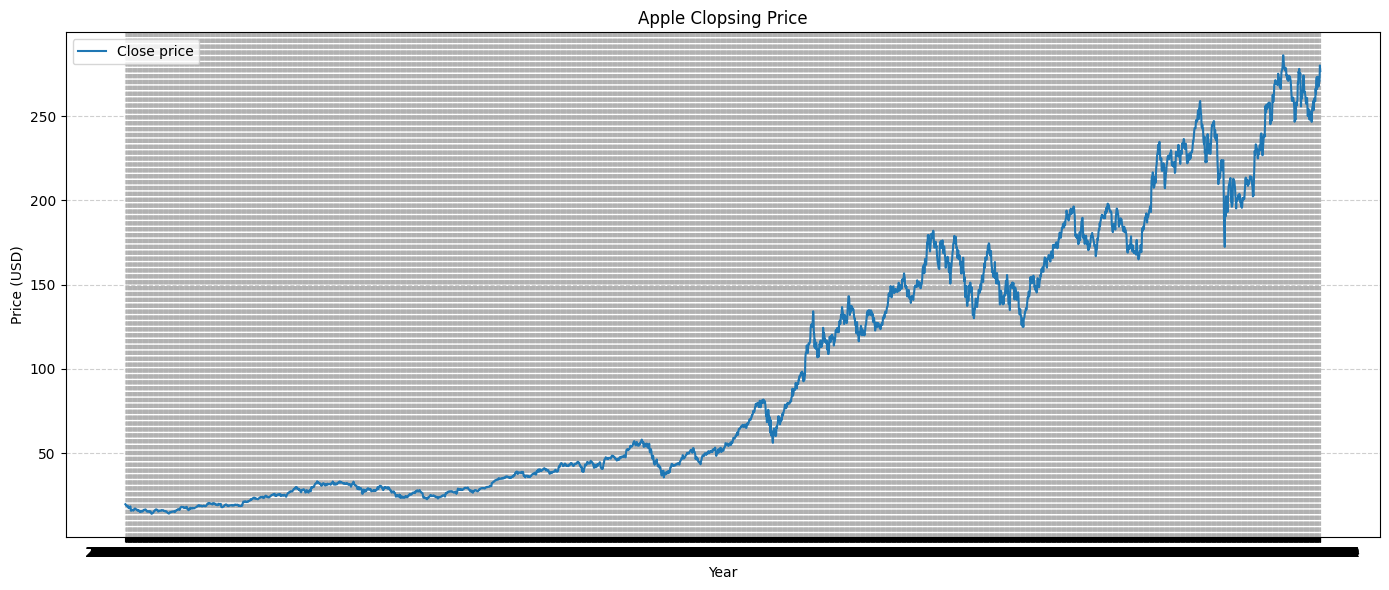

In [30]:
# Plot Apple's closing price over time
plt.figure(figsize=(14,6))

plt.plot(
    df.index,
    df['Close'],
    label = "Close price"
)

plt.title("Apple Clopsing Price")
plt.xlabel('Year')
plt.ylabel('Price (USD)')

plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()

plt.show()

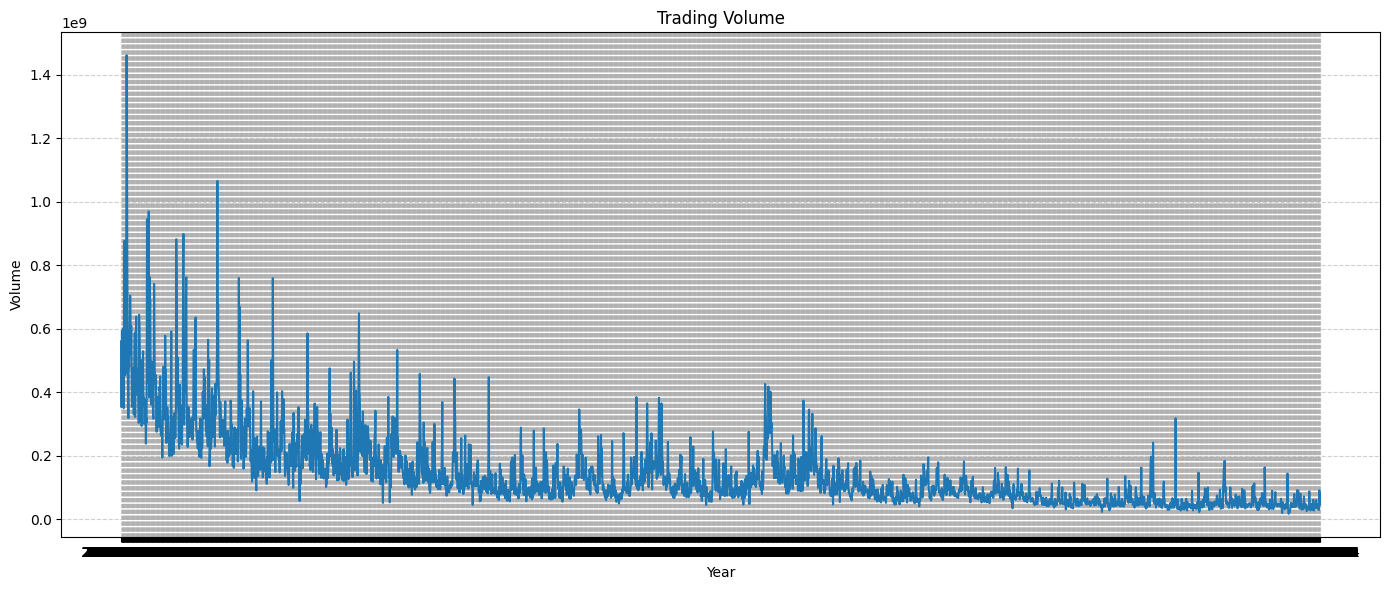

In [31]:
# Plot trading volume over time
plt.figure(figsize=(14,6))

plt.plot(
    df.index,
    df["Volume"]
)

plt.title("Trading Volume")

plt.xlabel("Year")

plt.ylabel("Volume")

plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()

plt.show()

In [32]:
# Compute correlation matrix
# Compute the correlation matrix
correlation_matrix = df.corr(numeric_only=True)

# Display it
print(correlation_matrix)

           Adj Close     Close      High       Low      Open    Volume
Adj Close   1.000000  0.999962  0.999843  0.999851  0.999704 -0.559340
Close       0.999962  1.000000  0.999882  0.999880  0.999738 -0.560088
High        0.999843  0.999882  1.000000  0.999832  0.999869 -0.558501
Low         0.999851  0.999880  0.999832  1.000000  0.999876 -0.561430
Open        0.999704  0.999738  0.999869  0.999876  1.000000 -0.559892
Volume     -0.559340 -0.560088 -0.558501 -0.561430 -0.559892  1.000000


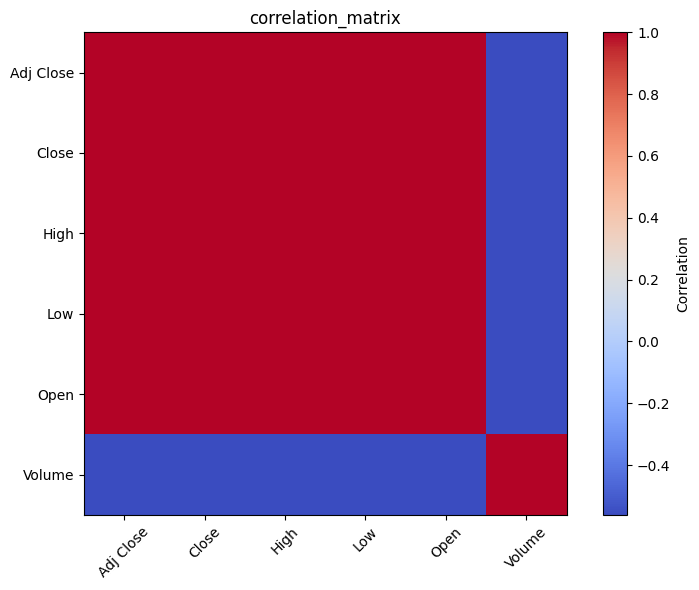

In [33]:
# Plot correlation heatmap

plt.figure(figsize=(8,6))

plt.imshow(correlation_matrix, cmap='coolwarm', interpolation = 'nearest')

plt.xticks(range(len(correlation_matrix.columns)),
            correlation_matrix.columns,
            rotation=45)

plt.yticks(range(len(correlation_matrix.columns)),
            correlation_matrix.columns)

plt.colorbar(label = "Correlation")
plt.title('correlation_matrix')

plt.tight_layout()

plt.show()

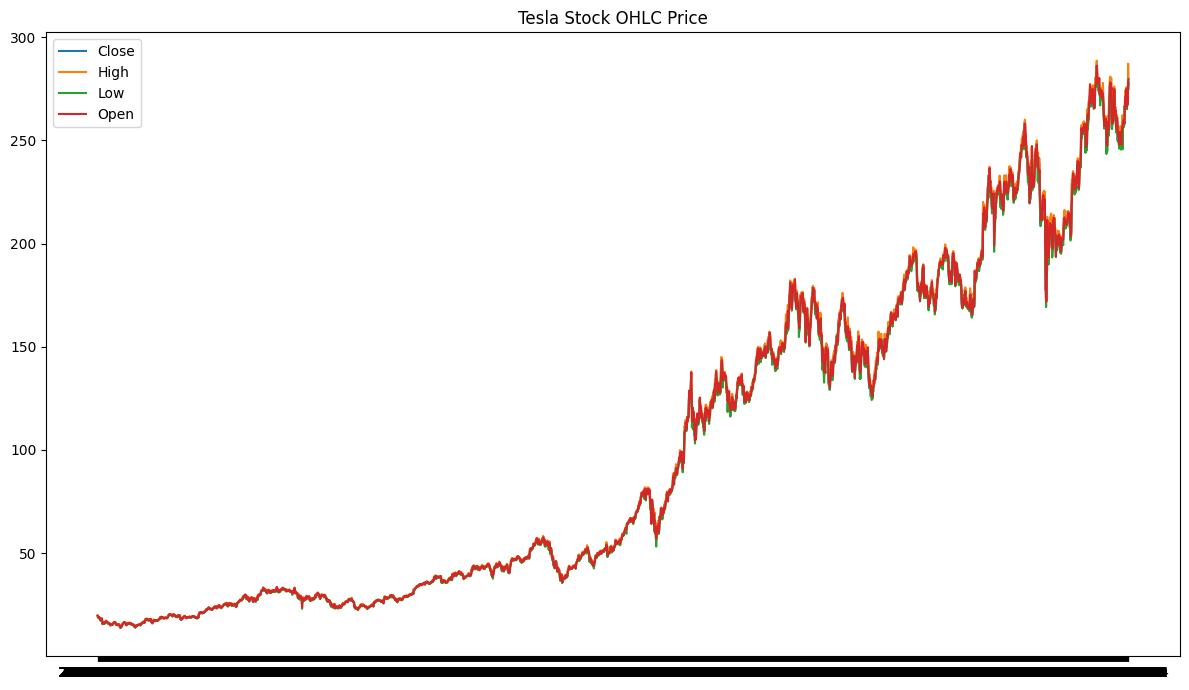

In [34]:
plt.figure(figsize=(12,7))
plt.plot(df.index, df.Close, label = "Close")
plt.plot(df.index, df.High, label = "High")
plt.plot(df.index, df.Low, label = "Low")
plt.plot(df.index, df.Open, label = "Open")
plt.title("Tesla Stock OHLC Price")
plt.legend()
plt.tight_layout()
plt.show()

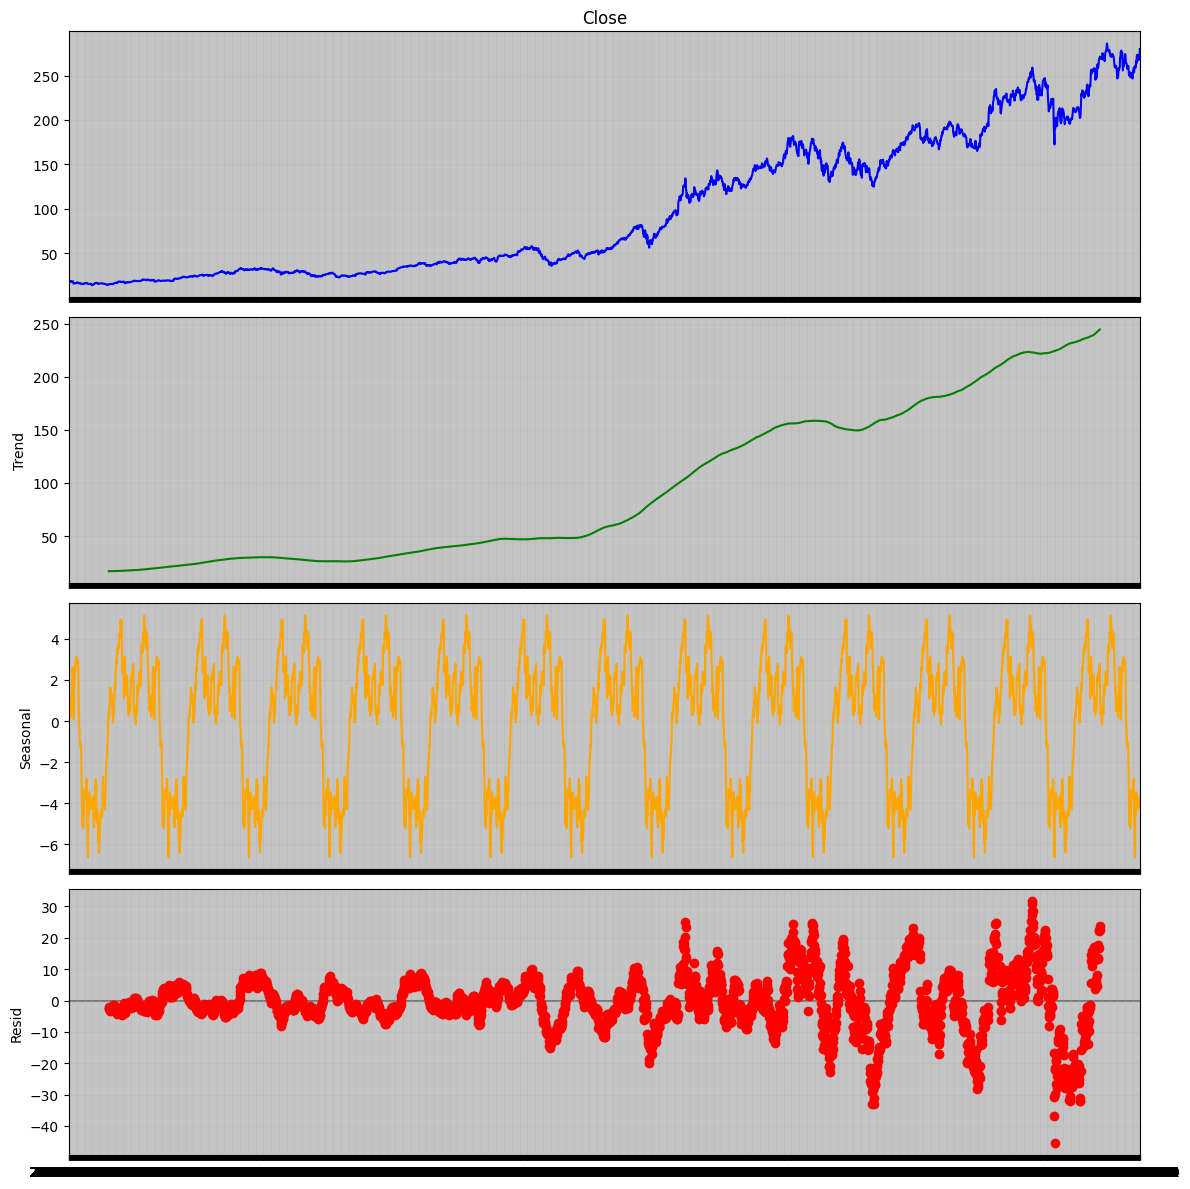

In [35]:
decompose = seasonal_decompose(df["Close"], model="additive", period=252)
fig = decompose.plot()
fig.set_size_inches(12,12)
colors = ["blue", "green", "orange", "red"]
for ax, color in zip(fig.axes, colors):
    ax.lines[0].set_color(color)
    ax.grid(alpha = 0.3)
plt.tight_layout()
plt.show()

In [36]:
from statsmodels.tsa.stattools import adfuller

In [37]:
adf_result = adfuller(df["Close"])
print(f"ADF Statistic : {adf_result[0]:.4f}")
print(f"P-value       : {adf_result[1]:.4f}")
print("\nCritical Values")

for key, value in adf_result[4].items():
    print(f"{key} : {value:.4f}")

ADF Statistic : 0.6619
P-value       : 0.9890

Critical Values
1% : -3.4323
5% : -2.8624
10% : -2.5672


We fail to reject the null hypothesis, So conclude that it has unit root.

In [38]:
from statsmodels.tsa.stattools import kpss
kpss_result = kpss(df["Close"], regression="c")
print(f"KPSS Statistic : {kpss_result[0]:.4f}")
print(f"P-value        : {kpss_result[1]:.4f}")

print("\nCritical Values")
for key, value in kpss_result[3].items():
    print(f"{key} : {value}")

KPSS Statistic : 8.2612
P-value        : 0.0100

Critical Values
10% : 0.347
5% : 0.463
2.5% : 0.574
1% : 0.739


First Order Differencing

In [39]:
df['Close_diff'] = df['Close'].diff()

In [40]:
df_diff = df.dropna()

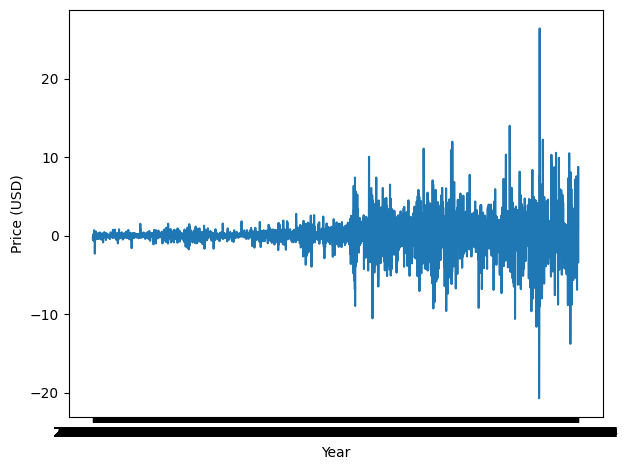

In [41]:
fig, ax = plt.subplots()

ax.plot(df_diff['Close_diff'])
ax.set_xlabel('Year')
ax.set_ylabel('Price (USD)')

plt.tight_layout()
plt.show()

In [42]:
adf_diff = adfuller(df_diff['Close_diff'])

print(f'ADF Statistic: {adf_diff[0]}')
print(f'p-value: {adf_diff[1]}')

ADF Statistic: -20.44635802227509
p-value: 0.0


In [43]:
from statsmodels.graphics.tsaplots import plot_acf

<Figure size 1200x500 with 0 Axes>

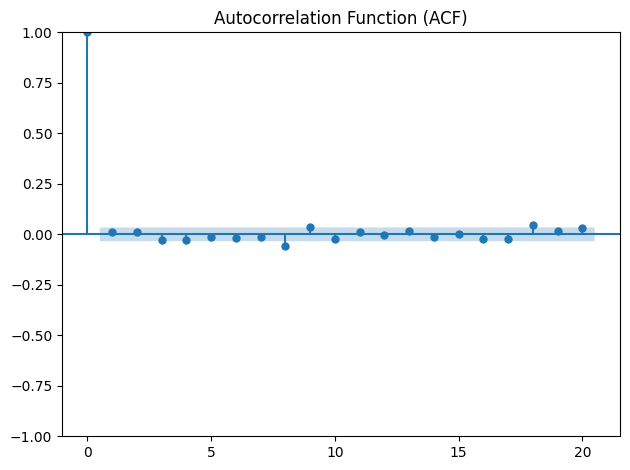

In [44]:
plt.figure(figsize=(12,5))
plot_acf(df_diff['Close_diff'], lags = 20)
plt.title("Autocorrelation Function (ACF)")
plt.tight_layout()
plt.show()

<Figure size 1200x500 with 0 Axes>

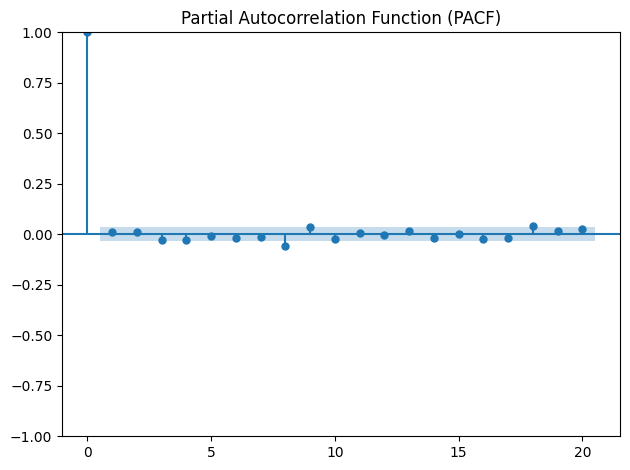

In [45]:
from statsmodels.graphics.tsaplots import plot_pacf
plt.figure(figsize=(12,5))
plot_pacf(df_diff['Close_diff'], lags = 20, method ='ywm')
plt.title("Partial Autocorrelation Function (PACF)")
plt.tight_layout()
plt.show()

In [46]:
#!pip install pmdarima

In [47]:
from pmdarima import auto_arima

model = auto_arima( df['Close'], start_p=0, start_q=0, max_p=2, max_q=2, d=None, seasonal=False, trace=True, error_action='ignore', suppress_warnings=True, stepwise=True)
print(model.summary())

Performing stepwise search to minimize aic
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=14716.989, Time=0.09 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=14718.434, Time=0.14 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=14718.445, Time=0.31 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=14719.174, Time=0.09 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=14720.947, Time=0.49 sec

Best model:  ARIMA(0,1,0)(0,0,0)[0] intercept
Total fit time: 1.144 seconds
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 3354
Model:               SARIMAX(0, 1, 0)   Log Likelihood               -7356.494
Date:                Mon, 17 Aug 2026   AIC                          14716.989
Time:                        17:06:00   BIC                          14729.224
Sample:                             0   HQIC                         14721.365
                               - 3354                                  

In [48]:
def compute_rsi(series, period=14):
    delta = series.diff()
    gain = delta.clip(lower=0)
    loss = -delta.clip(upper=0)

    avg_gain = gain.rolling(window=period).mean()
    avg_loss = loss.rolling(window=period).mean()

    rs = avg_gain / avg_loss
    rsi = 100 - (100 / (1 + rs))
    return rsi

df['RSI'] = compute_rsi(df['Close'], period=14)
df = df.dropna()

In [49]:
df.index = pd.to_datetime(df.index)
df = df.asfreq('B')
df = df.ffill()

In [50]:
len(df['Close'])

3464

In [51]:
df['Volume_lag1'] = df['Volume'].shift(1)
df['RSI'] = compute_rsi(df['Close'], period=14)
df = df.dropna()
train_size = int(len(df) * 0.8)
train = df['Close'].iloc[:train_size]
test  = df['Close'].iloc[train_size:]
exog_train = df[['Volume_lag1', 'RSI']].iloc[:train_size]
exog_test  = df[['Volume_lag1', 'RSI']].iloc[train_size:]
print(len(train), len(exog_train))
print(len(test), len(exog_test))
n_test = len(test)

2760 2760
690 690


In [52]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

In [53]:
# Naive forecast that "tomorrow = today" or a simple moving average
naive_forecast = [train.iloc[-1]] * n_test
naive_rmse = np.sqrt(mean_squared_error(test, naive_forecast))
mae = mean_absolute_error(test, naive_forecast)
print(f" MAE with exog : {mae:.4f}")
print(f"Naive RMSE: {naive_rmse:.4f}")

 MAE with exog : 43.1401
Naive RMSE: 52.4369


In [54]:
# Simple SARIMA (Without exogenous variable) that is ARIMA(0,1,0)
from statsmodels.tsa.statespace.sarimax import SARIMAX
model_plain = SARIMAX(train, order=(0,1,0))
results_plain = model_plain.fit(maxiter=1000)
forecast_plain = results_plain.get_forecast(steps=n_test)
predicted_plain = forecast_plain.predicted_mean

rmse_plain = np.sqrt(mean_squared_error(test, predicted_plain))
mae = mean_absolute_error(test, predicted_plain)
print(f"RMSE without exog: {rmse_plain:.4f}")
print(f" MAE without exog : {mae:.4f}")

RMSE without exog: 52.4369
 MAE without exog : 43.1401


In [55]:
# SARIMA with exogenous variables that is ARIMAX(0,1,0)
model = SARIMAX(train, exog=exog_train, order=(0,1,0))
results = model.fit(maxiter=1000, method = "powell")

forecast = results.get_forecast(steps=n_test, exog=exog_test)
predicted_mean = forecast.predicted_mean


Optimization terminated successfully.
         Current function value: 1.772824
         Iterations: 2
         Function evaluations: 88


In [56]:
# RMSE and MAE of SARIMAX(WITH EXOGENOUS VARIABLE) that is ARIMAX(0,1,0)
rmse = np.sqrt(mean_squared_error(test, predicted_mean))
mae = mean_absolute_error(test, predicted_mean)
print(f"RMSE with exog : {rmse:.4f}")
print(f" MAE with exog : {mae:.4f}")

RMSE with exog : 52.2706
 MAE with exog : 42.8737


Clearly, We can see that SRAIMAX (ARIMAX) with exogenous variable performs better in this case.


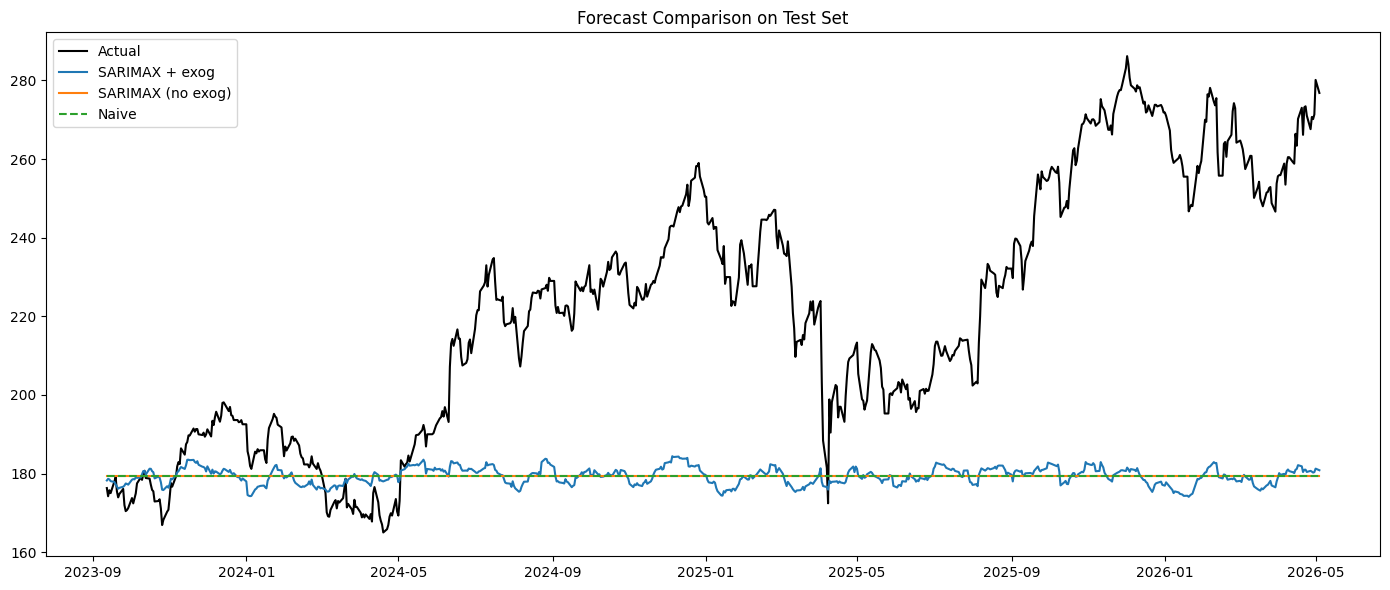

In [57]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))
plt.plot(test.index, test, label='Actual', color='black')
plt.plot(test.index, predicted_mean, label='SARIMAX + exog')
plt.plot(test.index, predicted_plain, label='SARIMAX (no exog)')
plt.plot(test.index, naive_forecast, label='Naive', linestyle='--')
plt.legend()
plt.title('Forecast Comparison on Test Set')
plt.tight_layout()
plt.show()

In [58]:
import numpy as np
import pandas as pd
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_squared_error, mean_absolute_error

step_size = 5
all_preds = []
all_actuals = []
all_dates = []
history = df['Close'].iloc[:train_size].copy()
history_exog = df[['Volume_lag1', 'RSI']].iloc[:train_size].copy()
test_full = df['Close'].iloc[train_size:]
test_exog_full = df[['Volume_lag1', 'RSI']].iloc[train_size:]
n = len(test_full)

for start in range(0, n, step_size):
    end = min(start + step_size, n)
    model = SARIMAX(history, exog=history_exog, order=(0,1,0))
    results = model.fit(maxiter=1000, method='powell', disp=False)
    exog_chunk = test_exog_full.iloc[start:end]
    forecast = results.get_forecast(steps=len(exog_chunk), exog=exog_chunk)
    pred = forecast.predicted_mean
    actual_chunk = test_full.iloc[start:end]
    all_preds.extend(pred.values)
    all_actuals.extend(actual_chunk.values)
    all_dates.extend(actual_chunk.index)
    history = pd.concat([history, actual_chunk])
    history_exog = pd.concat([history_exog, exog_chunk])

    print(f"Done: {end}/{n}")

rmse_wf = np.sqrt(mean_squared_error(all_actuals, all_preds))
mae_wf = mean_absolute_error(all_actuals, all_preds)
print(f"Walk-forward RMSE: {rmse_wf:.4f}")
print(f"Walk-forward MAE: {mae_wf:.4f}")

Done: 5/690
Done: 10/690
Done: 15/690
Done: 20/690
Done: 25/690
Done: 30/690
Done: 35/690
Done: 40/690
Done: 45/690
Done: 50/690
Done: 55/690
Done: 60/690
Done: 65/690
Done: 70/690
Done: 75/690
Done: 80/690
Done: 85/690
Done: 90/690
Done: 95/690
Done: 100/690
Done: 105/690
Done: 110/690
Done: 115/690
Done: 120/690
Done: 125/690
Done: 130/690
Done: 135/690
Done: 140/690
Done: 145/690
Done: 150/690
Done: 155/690
Done: 160/690
Done: 165/690
Done: 170/690
Done: 175/690
Done: 180/690
Done: 185/690
Done: 190/690
Done: 195/690
Done: 200/690
Done: 205/690
Done: 210/690
Done: 215/690
Done: 220/690
Done: 225/690
Done: 230/690
Done: 235/690
Done: 240/690
Done: 245/690
Done: 250/690
Done: 255/690
Done: 260/690
Done: 265/690
Done: 270/690
Done: 275/690
Done: 280/690
Done: 285/690
Done: 290/690
Done: 295/690
Done: 300/690
Done: 305/690
Done: 310/690
Done: 315/690
Done: 320/690
Done: 325/690
Done: 330/690
Done: 335/690
Done: 340/690
Done: 345/690
Done: 350/690
Done: 355/690
Done: 360/690
Done: 365/69

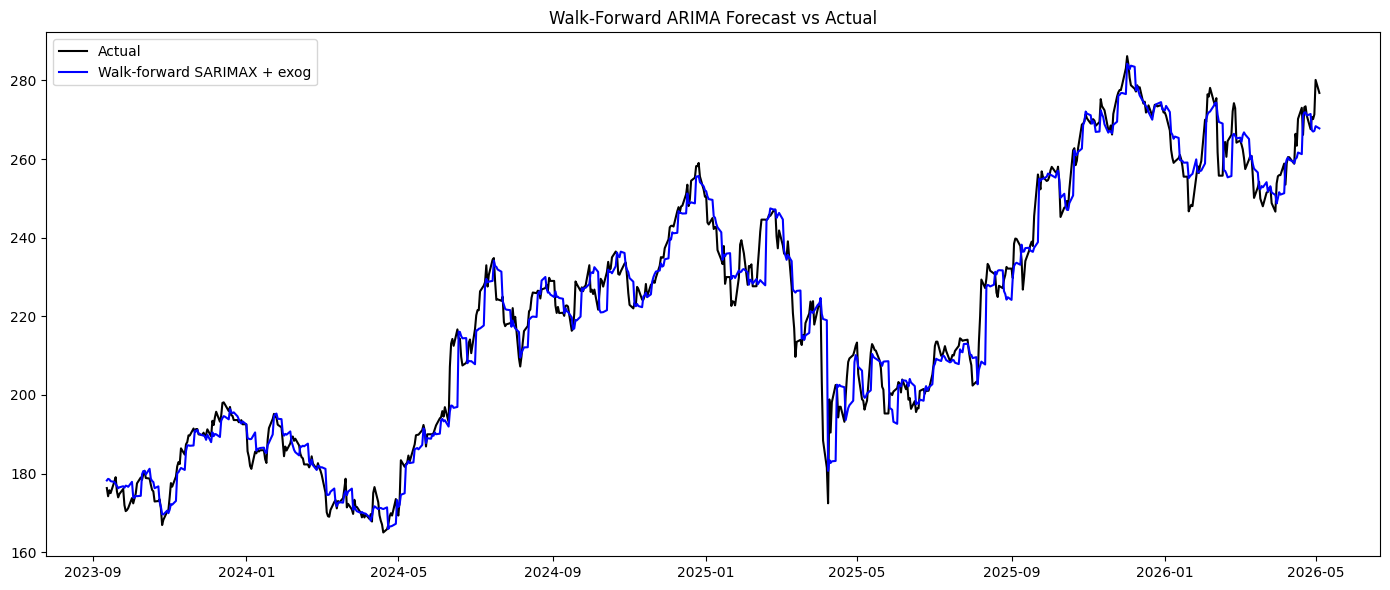

In [59]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))
plt.plot(all_dates, all_actuals, label='Actual', color='black')
plt.plot(all_dates, all_preds, label='Walk-forward SARIMAX + exog', color='blue')
plt.legend()
plt.title('Walk-Forward ARIMA Forecast vs Actual')
plt.tight_layout()
plt.show()

In [60]:
dt = df[['Close']]

In [61]:
import numpy as np
from sklearn.preprocessing import MinMaxScaler

In [62]:
training_size = int(len(dt) * 0.80)
test_size = len(dt) - training_size
train_raw = np.array(dt[:training_size]).reshape(-1,1)
test_raw = np.array(dt[training_size:]).reshape(-1,1)
scaler = MinMaxScaler(feature_range=(0,1))
train_data = scaler.fit_transform(train_raw)
test_data = scaler.transform(test_raw)

print(train_data.shape)
print(test_data.shape)

(2760, 1)
(690, 1)


In [63]:
train_data

array([[0.01514069],
       [0.01496652],
       [0.01488434],
       ...,
       [0.89649457],
       [0.89989176],
       [0.90635747]])

In [64]:
def create_dataset(dataset, time_step = 1):
  dataX, dataY = [], []
  for i in range(len(dataset)-time_step-1):
    a = dataset[i:(i+time_step), 0]
    dataX.append(a)
    dataY.append(dataset[i + time_step, 0])
  return numpy.array(dataX), numpy.array(dataY)

In [65]:
import numpy
# reshape into X=t, X=t+1, X=t+2, X=t+3 and Y=t+4
time_step = 100
X_train, y_train = create_dataset(train_data, time_step)
X_test, y_test = create_dataset(test_data, time_step)

In [66]:
X_train

array([[1.51406921e-02, 1.49665248e-02, 1.48843375e-02, ...,
        6.35995394e-04, 1.17415298e-03, 3.65748170e-03],
       [1.49665248e-02, 1.48843375e-02, 1.36260376e-02, ...,
        1.17415298e-03, 3.65748170e-03, 5.47154401e-03],
       [1.48843375e-02, 1.36260376e-02, 1.36260376e-02, ...,
        3.65748170e-03, 5.47154401e-03, 5.92359513e-03],
       ...,
       [8.42084396e-01, 8.36714546e-01, 8.27783218e-01, ...,
        9.61699208e-01, 9.61699208e-01, 9.63014205e-01],
       [8.36714546e-01, 8.27783218e-01, 8.29481812e-01, ...,
        9.61699208e-01, 9.63014205e-01, 9.25809271e-01],
       [8.27783218e-01, 8.29481812e-01, 8.20933997e-01, ...,
        9.63014205e-01, 9.25809271e-01, 8.96494570e-01]])

In [67]:
print(X_train.shape),  print(y_train.shape)

(2659, 100)
(2659,)


(None, None)

In [68]:
print(X_test.shape), print(y_test.shape)

(589, 100)
(589,)


(None, None)

In [69]:
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)


In [70]:
len(X_test)

589

In [71]:
model = Sequential()
model.add(LSTM(50, return_sequences=True, input_shape=(100,1)))
model.add(LSTM(50, return_sequences=True))
model.add(LSTM(50))
model.add(Dense(1))
model.compile(loss = "mean_squared_error", optimizer = 'adam')

In [72]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 100, 50)        │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 100, 50)        │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 50,851 (198.64 KB)

 Trainable params: 50,851 (198.64 KB)

 Non-trainable params: 0 (0.00 B)

In [73]:
model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=100, batch_size=64, verbose=1)

Epoch 1/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 6s 40ms/step - loss: 0.0237 - val_loss: 0.0051
Epoch 2/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 8.6528e-04 - val_loss: 0.0120
Epoch 3/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 6.2976e-04 - val_loss: 0.0104
Epoch 4/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 6.0602e-04 - val_loss: 0.0053
Epoch 5/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 6.3413e-04 - val_loss: 0.0144
Epoch 6/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 6.0302e-04 - val_loss: 0.0081
Epoch 7/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 5.6339e-04 - val_loss: 0.0081
Epoch 8/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 5.3172e-04 - val_loss: 0.0067
Epoch 9/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 5.6289e-04 - val_loss: 0.0085
Epoch 10/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 5.5591e-04 - val_loss: 0.0050
Epoch 11/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 5.0036e-04 - val_loss: 0.0044
Epoch 12/100

In [74]:
## Lets do the prediction and check performance metrics
train_predict=model.predict(X_train)
test_predict=model.predict(X_test)

84/84 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step


In [75]:
test_predict

array([[0.968887  ],
       [0.94789624],
       [0.92936873],
       [0.9454277 ],
       [0.93649274],
       [0.9467414 ],
       [0.95414186],
       [0.9533416 ],
       [0.9471752 ],
       [0.9511354 ],
       [0.9412098 ],
       [0.93046844],
       [0.92687213],
       [0.9255322 ],
       [0.9165578 ],
       [0.9172352 ],
       [0.91267115],
       [0.91703814],
       [0.9278684 ],
       [0.91627294],
       [0.9097933 ],
       [0.9189678 ],
       [0.9113599 ],
       [0.908263  ],
       [0.9026314 ],
       [0.87748426],
       [0.8517612 ],
       [0.8481812 ],
       [0.8471719 ],
       [0.85579234],
       [0.86564505],
       [0.86723036],
       [0.85549074],
       [0.86628693],
       [0.86411136],
       [0.87025845],
       [0.8831728 ],
       [0.89688474],
       [0.85644317],
       [0.86462224],
       [0.8570615 ],
       [0.8509083 ],
       [0.8706681 ],
       [0.85949326],
       [0.85950655],
       [0.8516233 ],
       [0.84528214],
       [0.849

In [76]:
len(test_predict)

589

In [77]:
import math

In [78]:
y_train_actual = scaler.inverse_transform(y_train.reshape(-1, 1))
y_test_actual = scaler.inverse_transform(y_test.reshape(-1, 1))

train_predict = scaler.inverse_transform(train_predict)
test_predict = scaler.inverse_transform(test_predict)

train_rmse = math.sqrt(mean_squared_error(y_train_actual, train_predict))
test_rmse = math.sqrt(mean_squared_error(y_test_actual, test_predict))

print(f"Train RMSE: {train_rmse:.4f}")
print(f"Test RMSE: {test_rmse:.4f}")

Train RMSE: 1.7290
Test RMSE: 4.8176


In [79]:
from sklearn.metrics import mean_absolute_error
test_mae = mean_absolute_error(y_test_actual, test_predict)
print(f"Test MAE: {test_mae:.4f}")

Test MAE: 3.7983


In [80]:
from sklearn.metrics import r2_score

print("LSTM R2:", r2_score(y_test_actual, test_predict))

LSTM R2: 0.9746969485330836


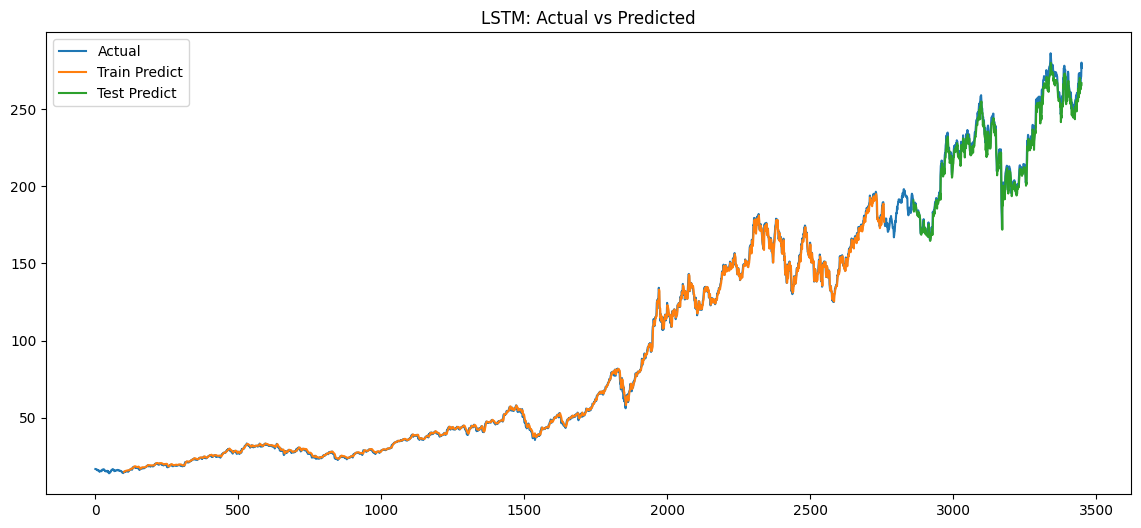

In [81]:
## Plotting
dt_values = dt.values
# shift train predictions for plotting
look_back=100
trainPredictPlot = numpy.empty_like(dt_values)
trainPredictPlot[:, :] = np.nan
trainPredictPlot[look_back:len(train_predict)+look_back, :] = train_predict
# shift test predictions for plotting
testPredictPlot = numpy.empty_like(dt_values)
testPredictPlot[:, :] = numpy.nan
testPredictPlot[len(train_predict)+(look_back*2)+1:len(dt_values)-1, :] = test_predict
# plot baseline and predictions
plt.figure(figsize=(14,6))
plt.plot(dt_values, label='Actual')
plt.plot(trainPredictPlot, label='Train Predict')
plt.plot(testPredictPlot, label='Test Predict')
plt.legend()
plt.title('LSTM: Actual vs Predicted')
plt.show()

**Now Model GRU**

In [82]:
model = Sequential()
model.add(GRU(50, return_sequences=True, input_shape=(100,1)))
model.add(GRU(50, return_sequences=True))
model.add(GRU(50))
model.add(Dense(1))
model.compile(loss = "mean_squared_error", optimizer = 'adam')

In [83]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 100, 50)        │         7,950 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 100, 50)        │        15,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_2 (GRU)                     │ (None, 50)             │        15,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 38,601 (150.79 KB)

 Trainable params: 38,601 (150.79 KB)

 Non-trainable params: 0 (0.00 B)

In [84]:
model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=100, batch_size=64, verbose=1)

Epoch 1/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - loss: 0.0241 - val_loss: 0.0052
Epoch 2/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 3.9507e-04 - val_loss: 0.0013
Epoch 3/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 2.2688e-04 - val_loss: 0.0024
Epoch 4/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 1.9883e-04 - val_loss: 0.0016
Epoch 5/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 1.8115e-04 - val_loss: 0.0020
Epoch 6/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 1.7119e-04 - val_loss: 0.0017
Epoch 7/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 1.6534e-04 - val_loss: 0.0012
Epoch 8/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 1.6429e-04 - val_loss: 0.0013
Epoch 9/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 1.5654e-04 - val_loss: 0.0020
Epoch 10/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 1.4577e-04 - val_loss: 0.0011
Epoch 11/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 1.5539e-04 - val_loss: 8.5166e-04
Epoch 12

In [85]:
train_predict=model.predict(X_train)
test_predict=model.predict(X_test)

84/84 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step


In [86]:
len(test_predict)

589

In [87]:
y_train_actual = scaler.inverse_transform(y_train.reshape(-1, 1))
y_test_actual = scaler.inverse_transform(y_test.reshape(-1, 1))

train_predict = scaler.inverse_transform(train_predict)
test_predict = scaler.inverse_transform(test_predict)

train_rmse = math.sqrt(mean_squared_error(y_train_actual, train_predict))
test_rmse = math.sqrt(mean_squared_error(y_test_actual, test_predict))

print(f"Train RMSE: {train_rmse:.4f}")
print(f"Test RMSE: {test_rmse:.4f}")

Train RMSE: 3.1546
Test RMSE: 4.5540


In [88]:
from sklearn.metrics import mean_absolute_error
test_mae = mean_absolute_error(y_test_actual, test_predict)
print(f"Test MAE: {test_mae:.4f}")

Test MAE: 3.4804


In [89]:
from sklearn.metrics import r2_score

print("GRU R2:", r2_score(y_test_actual, test_predict))

GRU R2: 0.9773904554390946


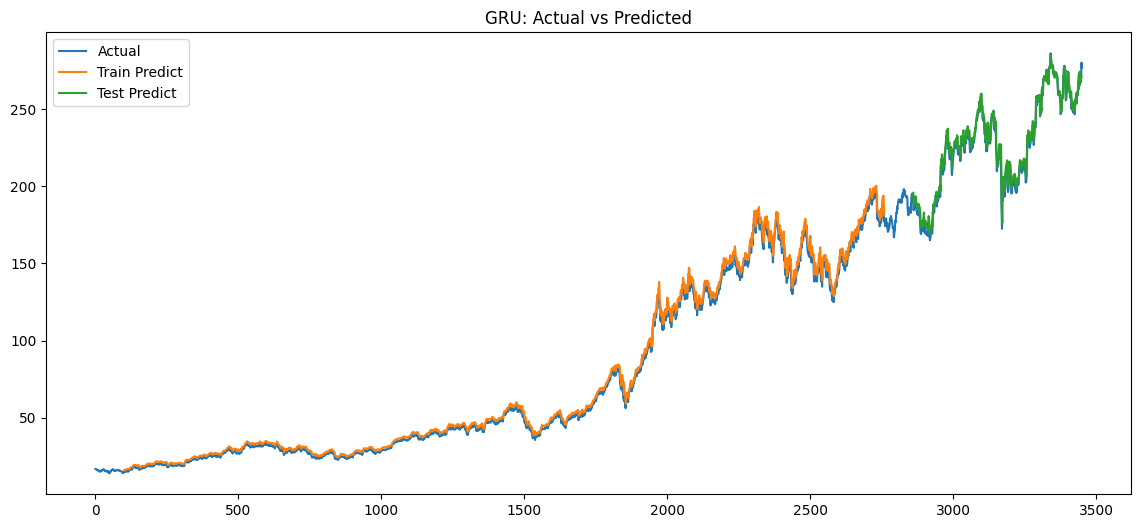

In [90]:
## Plotting
dt_values = dt.values
# shift train predictions for plotting
look_back=100
trainPredictPlot = numpy.empty_like(dt_values)
trainPredictPlot[:, :] = np.nan
trainPredictPlot[look_back:len(train_predict)+look_back, :] = train_predict
# shift test predictions for plotting
testPredictPlot = numpy.empty_like(dt_values)
testPredictPlot[:, :] = numpy.nan
testPredictPlot[len(train_predict)+(look_back*2)+1:len(dt_values)-1, :] = test_predict
# plot baseline and predictions
plt.figure(figsize=(14,6))
plt.plot(dt_values, label='Actual')
plt.plot(trainPredictPlot, label='Train Predict')
plt.plot(testPredictPlot, label='Test Predict')
plt.legend()
plt.title('GRU: Actual vs Predicted')
plt.show()

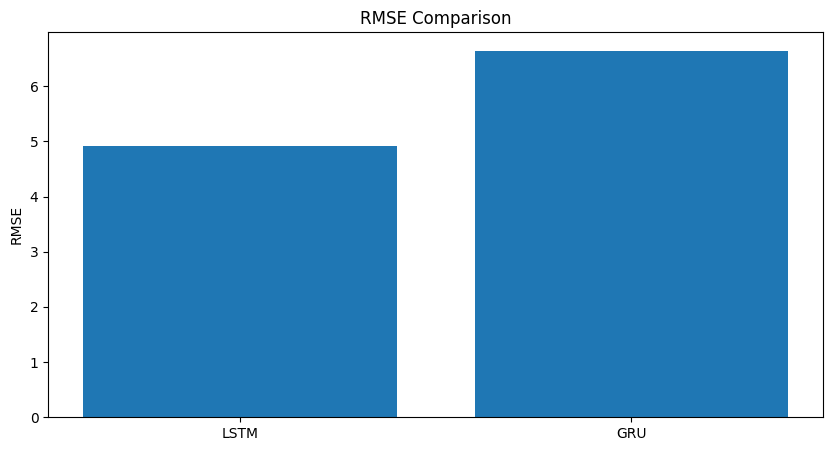

In [91]:
plt.figure(figsize=(10,5))

models = ["LSTM", "GRU"]
rmse = [4.9111, 6.6438]

plt.bar(models, rmse)

plt.title("RMSE Comparison")
plt.ylabel("RMSE")
plt.show()

### Best performining model is LSTM. So we will predict next 30 days using LSTM model

In [92]:
test_data

array([[0.88959059],
       [0.87813871],
       [0.88652215],
       [0.88252214],
       [0.89874113],
       [0.90476848],
       [0.8851523 ],
       [0.8766044 ],
       [0.88131667],
       [0.88838512],
       [0.86581011],
       [0.85742658],
       [0.85885128],
       [0.86170058],
       [0.87561816],
       [0.86822096],
       [0.87512503],
       [0.88197425],
       [0.89611106],
       [0.90433012],
       [0.90104246],
       [0.9087684 ],
       [0.91375466],
       [0.90356301],
       [0.90285067],
       [0.89424801],
       [0.88707003],
       [0.88498793],
       [0.87085113],
       [0.87150862],
       [0.87391956],
       [0.86109784],
       [0.83802963],
       [0.84531721],
       [0.85665948],
       [0.85928964],
       [0.87682363],
       [0.89654942],
       [0.89150832],
       [0.90564512],
       [0.91983677],
       [0.92569966],
       [0.92306958],
       [0.94493224],
       [0.93616529],
       [0.95063084],
       [0.95375404],
       [0.963

In [93]:
x_input = test_data[-100:].reshape(1,-1)
print(x_input.shape)

(1, 100)


In [94]:
temp_input = list(x_input)
temp_input = temp_input[0].tolist()
print(len(temp_input))

100


In [95]:
temp_input

[1.4282680500722646,
 1.413090235721969,
 1.415008051148099,
 1.4231175894444654,
 1.408323204405541,
 1.4159394516122672,
 1.423884615284526,
 1.423884615284526,
 1.4216380506101818,
 1.423610713316787,
 1.419884609808159,
 1.413199763065601,
 1.413199763065601,
 1.4085424263101234,
 1.3879947622101276,
 1.361145680678945,
 1.3500225518681734,
 1.342954275814244,
 1.3447623966794235,
 1.349584275276327,
 1.3539677100640652,
 1.3479952090984113,
 1.33840629918508,
 1.3237216087071062,
 1.3237216087071062,
 1.2753386989399436,
 1.2805440904568774,
 1.2843797213091372,
 1.2826810441789305,
 1.323064110210677,
 1.3387350484332945,
 1.3287078619281167,
 1.3387898957137698,
 1.3453652151126958,
 1.4030630492167913,
 1.400158986046018,
 1.4385693057625002,
 1.4353913406239875,
 1.4475007171794025,
 1.4283228973527398,
 1.423172269507622,
 1.4331447759496432,
 1.3576938135726933,
 1.3250914529804392,
 1.3250914529804392,
 1.3694744408798938,
 1.3720497548024526,
 1.3513923961415064,
 1.373309

In [96]:
# demonstrate prediction for next 30 days
from numpy import array

lst_output=[]
n_steps=100
i=0
while(i<30):

    if(len(temp_input)>100):
        #print(temp_input)
        x_input=np.array(temp_input[1:])
        print("{} day input {}".format(i,x_input))
        x_input=x_input.reshape(1,-1)
        x_input = x_input.reshape((1, n_steps, 1))
        #print(x_input)
        yhat = model.predict(x_input, verbose=0)
        print("{} day output {}".format(i,yhat))
        temp_input.extend(yhat[0].tolist())
        temp_input=temp_input[1:]
        #print(temp_input)
        lst_output.extend(yhat.tolist())
        i=i+1
    else:
        x_input = x_input.reshape((1, n_steps,1))
        yhat = model.predict(x_input, verbose=0)
        print(yhat[0])
        temp_input.extend(yhat[0].tolist())
        print(len(temp_input))
        lst_output.extend(yhat.tolist())
        i=i+1


print(lst_output)

[1.4310814]
101
1 day input [1.41309024 1.41500805 1.42311759 1.4083232  1.41593945 1.42388462
 1.42388462 1.42163805 1.42361071 1.41988461 1.41319976 1.41319976
 1.40854243 1.38799476 1.36114568 1.35002255 1.34295428 1.3447624
 1.34958428 1.35396771 1.34799521 1.3384063  1.32372161 1.32372161
 1.2753387  1.28054409 1.28437972 1.28268104 1.32306411 1.33873505
 1.32870786 1.3387899  1.34536522 1.40306305 1.40015899 1.43856931
 1.43539134 1.44750072 1.4283229  1.42317227 1.43314478 1.35769381
 1.32509145 1.32509145 1.36947444 1.37204975 1.3513924  1.3733099
 1.38207694 1.41473415 1.42618603 1.41917243 1.37111819 1.3740771
 1.3687621  1.3620224  1.3498035  1.33429677 1.34755693 1.35276224
 1.35265271 1.32498184 1.29407816 1.30887254 1.3165984  1.29309191
 1.28772214 1.28240714 1.30158496 1.30240684 1.3077766  1.30925606
 1.28684542 1.27495519 1.31418746 1.32426958 1.32585856 1.32585856
 1.34196786 1.31259848 1.34218708 1.35089927 1.35084459 1.343831
 1.34180349 1.38344679 1.36684428 1.404

In [97]:
future_actual = scaler.inverse_transform( np.array(lst_output).reshape(-1,1))
print(future_actual[:10])

[[275.12343133]
 [274.58671099]
 [274.0326076 ]
 [273.57081489]
 [273.13586908]
 [272.74413067]
 [272.39200993]
 [272.07502511]
 [271.78941243]
 [271.53186499]]


In [98]:
day_new = np.arange(1,101)
day_pred = np.arange(101,131)

In [99]:
len(dt)

3450

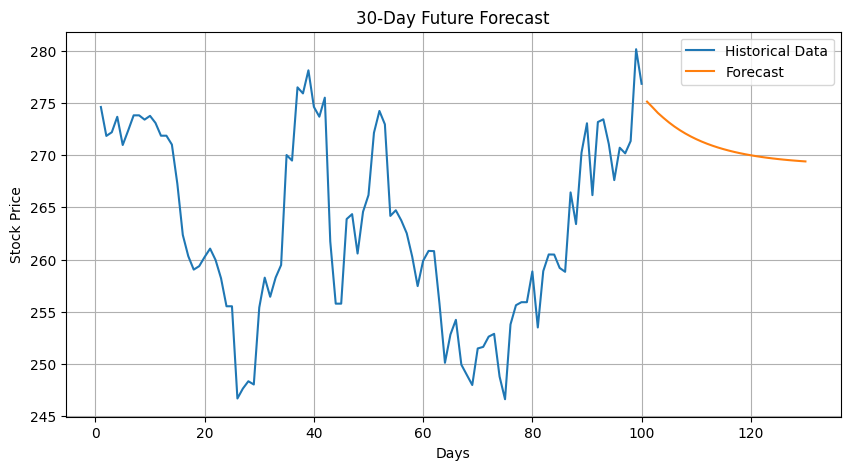

In [100]:
plt.figure(figsize=(10,5))
plt.plot(day_new, dt[3350:])
plt.plot( day_pred, scaler.inverse_transform(lst_output))
plt.title("30-Day Future Forecast")
plt.xlabel("Days")
plt.ylabel("Stock Price")
plt.legend(["Historical Data","Forecast"])
plt.grid(True)
plt.show()

In [101]:
dt1 = dt.values.tolist()
dt1.extend(scaler.inverse_transform(lst_output))

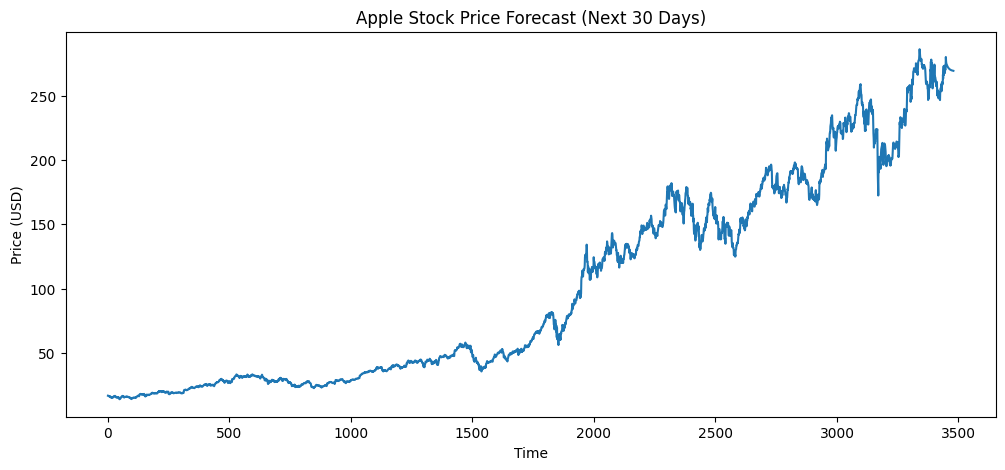

In [102]:
plt.figure(figsize=(12,5))
plt.plot(dt1)
plt.title("Apple Stock Price Forecast (Next 30 Days)")
plt.xlabel("Time")
plt.ylabel("Price (USD)")
plt.show()

##Volatility Forecasting


In [103]:
returns = 100 * df['Close'].pct_change().dropna()

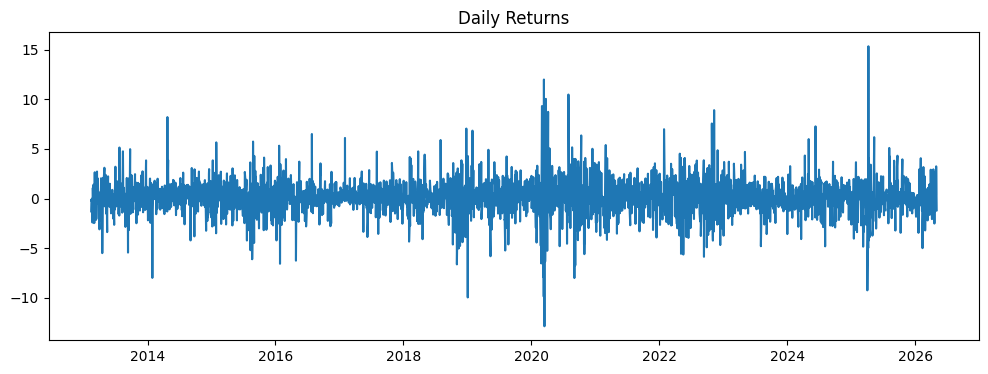

In [104]:
plt.figure(figsize=(12,4))
plt.plot(returns)
plt.title("Daily Returns")
plt.show()

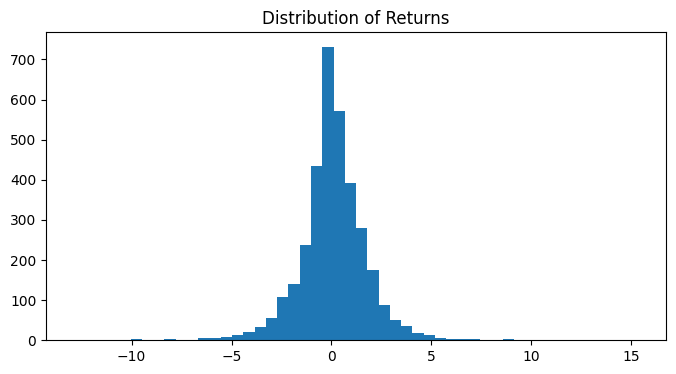

In [105]:
plt.figure(figsize=(8,4))
plt.hist(returns, bins=50)
plt.title("Distribution of Returns")
plt.show()

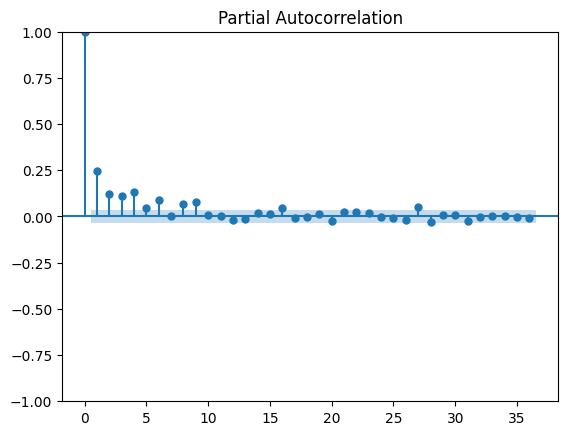

In [106]:
from statsmodels.graphics.tsaplots import plot_pacf
plot_pacf(returns**2)
plt.show()